# Two-island Model - Baboon data 

I denne notebook analyserer jeg genetiske data fra bavianer (*papio*) med en two-island model.

Two island model bygger på to populationer (øer):

- Har eksisteret længe uden split i modellen
- Udveksler migration konstant

Modelstruktur:

pop1 ↔ pop2

Ingen ancestral population i modellen (i modsætning til IM model).

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, 
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

# set_log_level('DEBUG')

## Eksempel simulation - Two-island model:

In [2]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

In [3]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


In [4]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


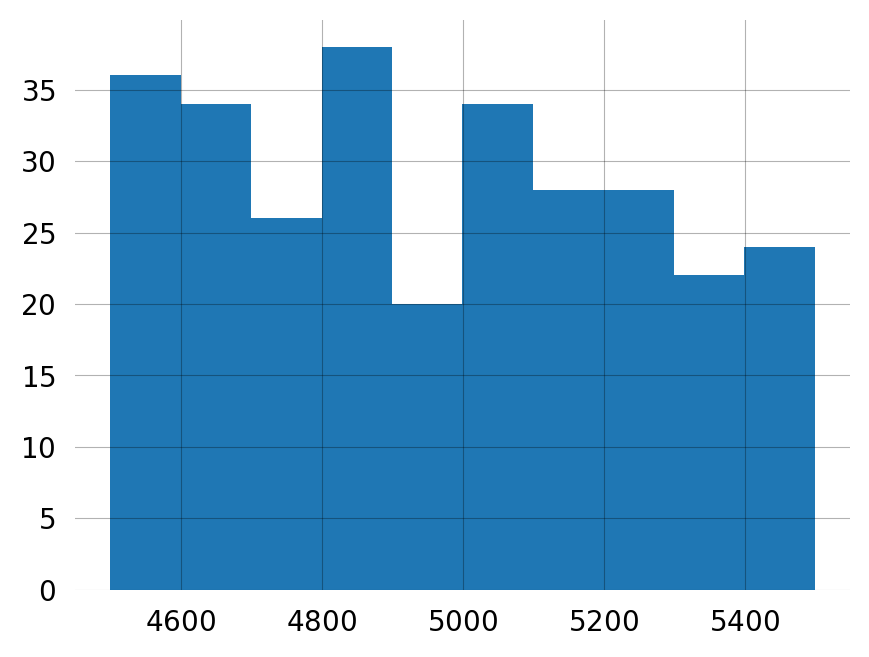

In [5]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [6]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [7]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## Baboon data

Load data for chromosome 20

In [9]:
import pandas as pd
import sgkit as sg

# load data for chr20
ds = sg.load_dataset("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz")

ds

<xarray.Dataset> Size: 3GB
Dimensions:               (variants: 2665269, samples: 227, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 605MB dask.array<chunksize=(1000, 227), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_id             (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                    ...
    variant_filter        (variants, filters) bool 3MB dask.array<chunksize=(1000, 1), meta=np.ndarray>
    variant_id            (variants) object 21MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_id_mask       (variants) bool 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_length        (variants) int8 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_position      (variants) int32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_quality       (variants) float32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    source:                bio2zarr-0.1.7
    vcf_meta_information:  [['fileformat', 'VCFv4.2'], ['fileDate', '06/07/20...
    vcf_zarr_version:      0.4

Jeg vælger to populationer GOG og Yellow Baboon

In [10]:
samples = ds["sample_id"].values

# Jeg vælger Filoha, Ethiopia, P. Hamadryas (pop2) og Gog, Ethiopia, P. anubis (pop1).
pop1 = [
    'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724','PD_0725','PD_0726',
    'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733',
    'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738', 'PD_0739', 'PD_0740',
    'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'
] #GOG

pop2 = [
    'PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701', 'PD_0702',
    'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
    'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 'PD_0716',
    'PD_0717', 'PD_0718', 'PD_0719'
] # Filoha


keep = pop1 + pop2
mask = ds["sample_id"].isin(keep).values
ds_sub = ds.isel(samples=mask)

print("Antal samples:", ds_sub.dims["samples"])

Antal samples: 49


/tmp/ipykernel_2745327/545421130.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Antal samples:", ds_sub.dims["samples"])


Derived allele counts 

In [11]:
variant_allele_counts = sg.count_variant_alleles(ds_sub)

ac = variant_allele_counts["variant_allele_count"].values

df = pd.DataFrame({
    "pos": ds_sub["variant_position"].values,
    "count": ac[:, 1]
}).sort_values("pos").reset_index(drop=True)

SNP paris

In [ ]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

distance, tolerance = 5000, 500

pairs_list = pairs_in_range(
    df["pos"].values,
    distance - tolerance,
    distance + tolerance
)

pairs = pd.DataFrame([
    (df.at[i, "pos"], df.at[j, "pos"], df.at[i, "count"], df.at[j, "count"])
    for i, j in pairs_list
], columns=["pos1", "pos2", "count1", "count2"])

Matrix

In [ ]:
nr_samples = ds_sub.dims["samples"]
n = len(pairs)

observations = np.zeros((n, nr_samples), dtype=int)

for i, (c1, c2) in enumerate(pairs[["count1", "count2"]].values):
    if c1 < nr_samples:
        observations[i, c1] = 1
    if c2 < nr_samples:
        observations[i, c2] = 1

print(observations.shape)

### Two-island model: 

pop1 ↔ pop2

- Ingen split
- Konstant migration i begge retninger

In [ ]:
graph = Graph()

graph.add_population("pop1")
graph.add_population("pop2")

# migration begge veje
graph.add_migration("pop1", "pop2", rate="m12")
graph.add_migration("pop2", "pop1", rate="m21")

In [ ]:
priors = PropertySet(
    m12=HalfCauchyPrior(1e-4),
    m21=HalfCauchyPrior(1e-4),
)

In [ ]:
result = graph.fit(
    observations=observations,
    priors=priors,
    optimizer=Adamelia(
        step_size=ExpStepSize(0.05),
        regularization=ExpRegularization(1e-3)
    ),
    steps=500
)

print(result)

In [ ]:
sns.kdeplot(result.samples["m12"], label="pop1 → pop2")
sns.kdeplot(result.samples["m21"], label="pop2 → pop1")

plt.legend()
plt.title("Posterior migration rates")
plt.show()

### Fortolkning

Denne model tester om:

- populationerne opfører sig som to kontinuerligt interagerende øer

Hvis modellen passer dårligt:
→ evidens for:
    - historisk split (IM model bedre)
    - eller ghost populations

I baboon data forventer man ofte:

- kompleks struktur
- admixture
- ikke en simpel two-island model